In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
MODEL_SAVE_DIR = '/content/drive/MyDrive/MotionGuardAI/models'
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
print(f"✅ Drive mounted\n📁 Model sẽ lưu tại: {MODEL_SAVE_DIR}")

Mounted at /content/drive
✅ Drive mounted
📁 Model sẽ lưu tại: /content/drive/MyDrive/MotionGuardAI/models


In [2]:
import cv2, os, time, warnings
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
warnings.filterwarnings('ignore')

print("✅ Packages OK — OpenCV", cv2.__version__)

✅ Packages OK — OpenCV 4.13.0


In [3]:
# ===========================================================
# CELL 3 — KAGGLE AUTHENTICATION
# ===========================================================
# Bạn cần API key từ https://www.kaggle.com/settings → API → Create New Token
# File tải về tên là kaggle.json
#
# CÁCH 1 (đơn giản): Upload kaggle.json thủ công
# --------------------------------------------------
from google.colab import files
print("📎 Hãy upload file kaggle.json của bạn:")
uploaded = files.upload()   # chọn kaggle.json

import os, shutil
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
shutil.copy("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
print("✅ Kaggle API key đã được cài đặt")

📎 Hãy upload file kaggle.json của bạn:


Saving kaggle.json to kaggle.json
✅ Kaggle API key đã được cài đặt


In [4]:
# ===========================================================
# CELL 4 — TẢI INRIA DATASET TỪ KAGGLE
# ===========================================================
import kagglehub

print("📥 Đang tải INRIA Person Dataset từ Kaggle...")
DATASET_PATH = kagglehub.dataset_download("jcoral02/inriaperson")
print(f"✅ Dataset tải về tại: {DATASET_PATH}")

# Xem cấu trúc thư mục sau khi tải
print("\n📂 Cấu trúc thư mục:")
for root, dirs, files_list in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, '').count(os.sep)
    indent = '  ' * level
    folder_name = os.path.basename(root)
    n_files = len(files_list)
    if level <= 3:
        print(f"{indent}📁 {folder_name}/  ({n_files} files)")

📥 Đang tải INRIA Person Dataset từ Kaggle...


100%|██████████| 582M/582M [00:05<00:00, 102MB/s]

Extracting files...


✅ Dataset tải về tại: /root/.cache/kagglehub/datasets/jcoral02/inriaperson/versions/1

📂 Cấu trúc thư mục:
📁 1/  (0 files)
  📁 Test/  (0 files)
    📁 JPEGImages/  (288 files)
    📁 Annotations/  (288 files)
  📁 Train/  (0 files)
    📁 JPEGImages/  (614 files)
    📁 Annotations/  (614 files)


📊 Dataset Summary:
  Train → Positive (người) :   614 ảnh
  Train → Negative (nền)   :   614 ảnh  (random patch từ cùng ảnh)
  Test  → Positive         :   288 ảnh
  Test  → Negative         :   288 ảnh


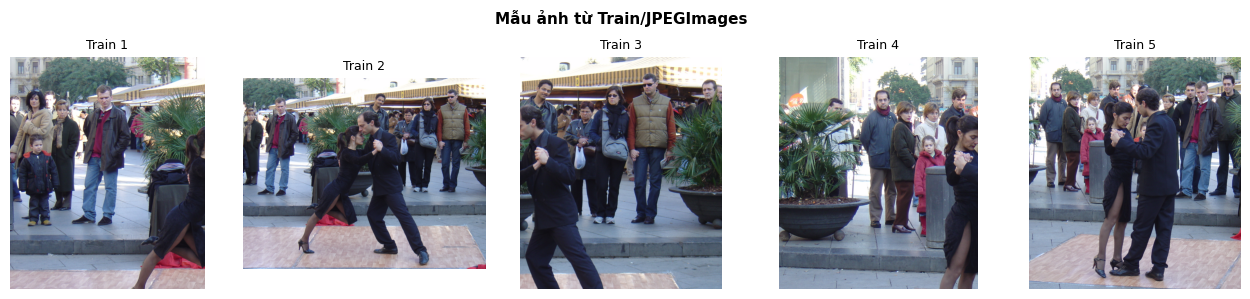

In [5]:
# ===========================================================
# CELL 5 — TÌM ĐƯỜNG DẪN ẢNH TRONG DATASET (đã sửa)
# ===========================================================
from pathlib import Path

def find_image_paths(base_dir):
    """
    Hỗ trợ cấu trúc INRIA từ Kaggle jcoral02/inriaperson:
        Train/JPEGImages/  →  ảnh positive (có người)
        Test/JPEGImages/   →  ảnh positive (test)
    Negative sẽ được tạo bằng cách cắt random patch từ chính
    các ảnh đó (vùng ngoài người) — đủ để train LinearSVC.
    """
    base = Path(base_dir)
    exts = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}

    def collect(folder):
        return sorted([
            str(p) for p in folder.rglob('*')
            if p.suffix in exts
        ])

    # ── Tìm thư mục Train / Test ──────────────────────────
    train_dirs = list(base.rglob('Train')) + list(base.rglob('train')) + \
                 list(base.rglob('Training')) + list(base.rglob('training'))
    test_dirs  = list(base.rglob('Test'))  + list(base.rglob('test'))

    pos_train, pos_test = [], []

    for d in train_dirs:
        # Ưu tiên thư mục JPEGImages hoặc pos bên trong
        jpeg_sub = list(d.rglob('JPEGImages'))
        pos_sub  = [x for x in d.rglob('*') if 'pos' in x.name.lower()]
        if jpeg_sub:
            pos_train += collect(jpeg_sub[0])
        elif pos_sub:
            pos_train += collect(pos_sub[0])
        else:
            pos_train += collect(d)

    for d in test_dirs:
        jpeg_sub = list(d.rglob('JPEGImages'))
        pos_sub  = [x for x in d.rglob('*') if 'pos' in x.name.lower()]
        if jpeg_sub:
            pos_test += collect(jpeg_sub[0])
        elif pos_sub:
            pos_test += collect(pos_sub[0])
        else:
            pos_test += collect(d)

    # Fallback: nếu vẫn trống → quét toàn bộ dataset
    if not pos_train and not pos_test:
        all_imgs = collect(base)
        split    = int(len(all_imgs) * 0.8)
        pos_train, pos_test = all_imgs[:split], all_imgs[split:]
        print("⚠️  Fallback: dùng toàn bộ ảnh, tự split 80/20")

    # Dedup
    pos_train = list(dict.fromkeys(pos_train))
    pos_test  = list(dict.fromkeys(pos_test))

    # ── Negative = dùng cùng ảnh đó, extract_negative_features
    #    sẽ lấy random patch → phần lớn là background ─────────
    neg_train = pos_train   # reuse — patches sẽ được crop ngẫu nhiên
    neg_test  = pos_test

    return pos_train, neg_train, pos_test, neg_test


pos_train_paths, neg_train_paths, pos_test_paths, neg_test_paths = find_image_paths(DATASET_PATH)

print("📊 Dataset Summary:")
print(f"  Train → Positive (người) : {len(pos_train_paths):>5} ảnh")
print(f"  Train → Negative (nền)   : {len(neg_train_paths):>5} ảnh  (random patch từ cùng ảnh)")
print(f"  Test  → Positive         : {len(pos_test_paths):>5} ảnh")
print(f"  Test  → Negative         : {len(neg_test_paths):>5} ảnh")

assert len(pos_train_paths) > 0, "❌ Vẫn không tìm được ảnh! In DATASET_PATH để kiểm tra."
assert len(pos_test_paths)  > 0, "❌ Không có ảnh test!"

# Hiển thị mẫu
fig, axes = plt.subplots(1, 5, figsize=(13, 3))
for i, ax in enumerate(axes):
    img = cv2.cvtColor(cv2.imread(pos_train_paths[i]), cv2.COLOR_BGR2RGB)
    ax.imshow(img); ax.set_title(f'Train {i+1}', fontsize=9); ax.axis('off')
plt.suptitle('Mẫu ảnh từ Train/JPEGImages', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

In [6]:
# ===========================================================
# CELL 6 — CẤU HÌNH HOG + TÍNH FEATURE DIMENSION
# ===========================================================
# Tham số HOG chuẩn theo Dalal & Triggs (CVPR 2005)
WIN_W,   WIN_H   = 64, 128   # Detection window (width × height)
CELL_W,  CELL_H  = 8,  8    # Pixels per cell
BLOCK_W, BLOCK_H = 16, 16   # Pixels per block  (2×2 cells)
BSTRIDE_W        = 8        # Block stride (50% overlap)
BSTRIDE_H        = 8
N_BINS           = 9        # Orientation histogram bins (0°–180°)

hog = cv2.HOGDescriptor(
    _winSize     = (WIN_W, WIN_H),
    _blockSize   = (BLOCK_W, BLOCK_H),
    _blockStride = (BSTRIDE_W, BSTRIDE_H),
    _cellSize    = (CELL_W, CELL_H),
    _nbins       = N_BINS
)
FEATURE_DIM = int(hog.getDescriptorSize())   # = 3780

# Tính thủ công để kiểm chứng
n_cells_x       = WIN_W // CELL_W                              # 8
n_cells_y       = WIN_H // CELL_H                              # 16
n_blocks_x      = (WIN_W  - BLOCK_W) // BSTRIDE_W + 1         # 7
n_blocks_y      = (WIN_H  - BLOCK_H) // BSTRIDE_H + 1         # 15
n_blocks        = n_blocks_x * n_blocks_y                      # 105
cells_per_block = (BLOCK_W // CELL_W) * (BLOCK_H // CELL_H)   # 4

print("═"*55)
print("⚙️  CẤU HÌNH HOG DESCRIPTOR")
print("═"*55)
print(f"  Detection window  : {WIN_W} × {WIN_H} px")
print(f"  Cell size         : {CELL_W} × {CELL_H} px")
print(f"  Block size        : {BLOCK_W} × {BLOCK_H} px  ({BLOCK_W//CELL_W}×{BLOCK_H//CELL_H} cells)")
print(f"  Block stride      : {BSTRIDE_W} × {BSTRIDE_H} px  (overlap 50%)")
print(f"  Orientation bins  : {N_BINS}")
print()
print(f"  Cells in window   : {n_cells_x} × {n_cells_y} = {n_cells_x*n_cells_y}")
print(f"  Blocks in window  : {n_blocks_x} × {n_blocks_y} = {n_blocks}")
print(f"  Feats per block   : {cells_per_block} cells × {N_BINS} bins = {cells_per_block*N_BINS}")
print(f"  ✅ TOTAL FEATURES  : {n_blocks} × {cells_per_block*N_BINS} = {FEATURE_DIM}")
assert FEATURE_DIM == 3780, f"Expected 3780, got {FEATURE_DIM}"


═══════════════════════════════════════════════════════
⚙️  CẤU HÌNH HOG DESCRIPTOR
═══════════════════════════════════════════════════════
  Detection window  : 64 × 128 px
  Cell size         : 8 × 8 px
  Block size        : 16 × 16 px  (2×2 cells)
  Block stride      : 8 × 8 px  (overlap 50%)
  Orientation bins  : 9

  Cells in window   : 8 × 16 = 128
  Blocks in window  : 7 × 15 = 105
  Feats per block   : 4 cells × 9 bins = 36
  ✅ TOTAL FEATURES  : 105 × 36 = 3780


In [7]:
# ===========================================================
# CELL 7 — TRÍCH XUẤT HOG FEATURES
# ===========================================================
def extract_hog(img_or_path):
    """Đọc ảnh (hoặc dùng array), resize về WIN_W×WIN_H, trả về HOG features."""
    img = cv2.imread(img_or_path) if isinstance(img_or_path, str) else img_or_path
    if img is None:
        return None
    resized = cv2.resize(img, (WIN_W, WIN_H))
    gray    = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY) if len(resized.shape) == 3 else resized
    return hog.compute(gray).flatten().astype(np.float32)


def extract_positive_features(paths, desc="Positive"):
    feats = []
    for p in tqdm(paths, desc=f"  HOG {desc}"):
        f = extract_hog(p)
        if f is not None:
            feats.append(f)
    return np.array(feats, dtype=np.float32)


def extract_negative_features(paths, patches_per_img=12, seed=42, desc="Negative"):
    """Lấy ngẫu nhiên nhiều patches từ mỗi ảnh nền."""
    rng   = np.random.default_rng(seed)
    feats = []
    for p in tqdm(paths, desc=f"  HOG {desc}"):
        img = cv2.imread(str(p))
        if img is None: continue
        h, w = img.shape[:2]
        if h < WIN_H or w < WIN_W: continue
        for _ in range(patches_per_img):
            y = rng.integers(0, h - WIN_H)
            x = rng.integers(0, w - WIN_W)
            f = extract_hog(img[y:y+WIN_H, x:x+WIN_W])
            if f is not None:
                feats.append(f)
    return np.array(feats, dtype=np.float32)


print("🔄 Trích xuất HOG features từ dataset...")
X_pos_tr = extract_positive_features(pos_train_paths, "Train-Positive")
X_neg_tr = extract_negative_features(neg_train_paths, patches_per_img=10, desc="Train-Negative")
X_pos_te = extract_positive_features(pos_test_paths,  "Test-Positive")
X_neg_te = extract_negative_features(neg_test_paths,  patches_per_img=5,  desc="Test-Negative")

X_train = np.vstack([X_pos_tr, X_neg_tr])
y_train = np.hstack([np.ones(len(X_pos_tr)), np.zeros(len(X_neg_tr))]).astype(int)
X_test  = np.vstack([X_pos_te, X_neg_te])
y_test  = np.hstack([np.ones(len(X_pos_te)), np.zeros(len(X_neg_te))]).astype(int)

print(f"\n📊 Sau feature extraction:")
print(f"  Train : {len(X_train):,}  ({len(X_pos_tr)} người  +  {len(X_neg_tr)} nền)")
print(f"  Test  : {len(X_test):,}  ({len(X_pos_te)} người  +  {len(X_neg_te)} nền)")
print(f"  Mỗi sample : {FEATURE_DIM} features")
print(f"  RAM dùng   : {X_train.nbytes/1e6:.1f} MB (train) + {X_test.nbytes/1e6:.1f} MB (test)")

🔄 Trích xuất HOG features từ dataset...


  HOG Test-Negative: 100%|██████████| 288/288 [00:04<00:00, 63.70it/s]



📊 Sau feature extraction:
  Train : 6,754  (614 người  +  6140 nền)
  Test  : 1,728  (288 người  +  1440 nền)
  Mỗi sample : 3780 features
  RAM dùng   : 102.1 MB (train) + 26.1 MB (test)


In [8]:
# ===========================================================
# CELL 8 — TRAIN LinearSVC (ROUND 1)
# ===========================================================
print("🏋️  Training LinearSVC (round 1 / 2)...")
t0  = time.time()
clf = LinearSVC(C=0.01, max_iter=5000, random_state=42, dual=True)
clf.fit(X_train, y_train)
print(f"⏱  Xong trong {time.time()-t0:.1f}s")

y_pred_r1 = clf.predict(X_test)
print(f"\n  Train accuracy : {clf.score(X_train, y_train):.4f}")
print(f"  Test accuracy  : {accuracy_score(y_test, y_pred_r1):.4f}")
print()
print(classification_report(y_test, y_pred_r1,
                             target_names=['Nền (Background)', 'Người (Person)']))


🏋️  Training LinearSVC (round 1 / 2)...
⏱  Xong trong 2.3s

  Train accuracy : 0.9474
  Test accuracy  : 0.8860

                  precision    recall  f1-score   support

Nền (Background)       0.89      0.99      0.94      1440
  Người (Person)       0.88      0.36      0.52       288

        accuracy                           0.89      1728
       macro avg       0.88      0.68      0.73      1728
    weighted avg       0.89      0.89      0.87      1728



In [9]:
# ===========================================================
# CELL 9 — HARD NEGATIVE MINING + RETRAIN (ROUND 2)
# ===========================================================
# Tìm ảnh nền bị dự đoán nhầm là người → thêm vào train
# để model cứng hơn với false positive.

def hard_negative_mining(clf, neg_paths, patches=60, max_fp_per_img=5, seed=99):
    rng    = np.random.default_rng(seed)
    h_negs = []
    for p in tqdm(neg_paths, desc="  Mining hard negatives"):
        img = cv2.imread(str(p))
        if img is None: continue
        h, w = img.shape[:2]
        if h < WIN_H or w < WIN_W: continue
        fp_found = 0
        for _ in range(patches):
            y = rng.integers(0, h - WIN_H)
            x = rng.integers(0, w - WIN_W)
            feat = extract_hog(img[y:y+WIN_H, x:x+WIN_W])
            if feat is not None and clf.predict([feat])[0] == 1:
                h_negs.append(feat)
                fp_found += 1
                if fp_found >= max_fp_per_img:
                    break
    return np.array(h_negs, np.float32) if h_negs else np.zeros((0, FEATURE_DIM), np.float32)


print("⛏️  Hard Negative Mining...")
X_hard = hard_negative_mining(clf, neg_train_paths)
print(f"  → Tìm thấy {len(X_hard)} hard negatives")

if len(X_hard) > 0:
    X_tr2 = np.vstack([X_train, X_hard])
    y_tr2 = np.hstack([y_train, np.zeros(len(X_hard), int)])
    print(f"\n🏋️  Retrain với hard negatives (round 2 / 2)...")
    print(f"  Tổng samples: {len(X_tr2):,}")
    t0        = time.time()
    clf_final = LinearSVC(C=0.01, max_iter=5000, random_state=42, dual=True)
    clf_final.fit(X_tr2, y_tr2)
    print(f"⏱  Xong trong {time.time()-t0:.1f}s")
else:
    clf_final = clf
    X_tr2     = X_train
    print("  Không có hard neg → giữ nguyên round 1")

y_pred = clf_final.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f"\n📊 KẾT QUẢ CUỐI (sau hard negative mining):")
print(f"  Test accuracy : {acc:.4f}  ({acc:.2%})")
print()
print(classification_report(y_test, y_pred, target_names=['Nền', 'Người']))

⛏️  Hard Negative Mining...


  Mining hard negatives: 100%|██████████| 614/614 [00:22<00:00, 26.85it/s]


  → Tìm thấy 383 hard negatives

🏋️  Retrain với hard negatives (round 2 / 2)...
  Tổng samples: 7,137
⏱  Xong trong 2.3s

📊 KẾT QUẢ CUỐI (sau hard negative mining):
  Test accuracy : 0.8542  (85.42%)

              precision    recall  f1-score   support

         Nền       0.85      1.00      0.92      1440
       Người       1.00      0.12      0.22       288

    accuracy                           0.85      1728
   macro avg       0.93      0.56      0.57      1728
weighted avg       0.88      0.85      0.80      1728



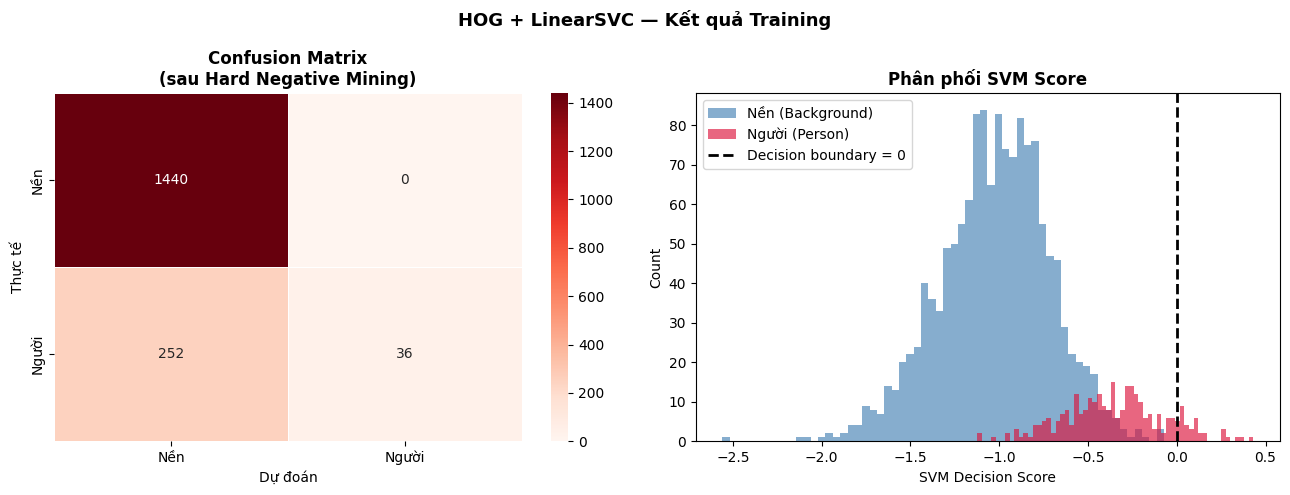

✅ Lưu biểu đồ → /content/drive/MyDrive/MotionGuardAI/models/training_results.png


In [10]:
# ===========================================================
# CELL 10 — VISUALIZATION
# ===========================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', linewidths=.5,
            xticklabels=['Nền', 'Người'],
            yticklabels=['Nền', 'Người'], ax=axes[0])
axes[0].set_title('Confusion Matrix\n(sau Hard Negative Mining)', fontweight='bold')
axes[0].set_ylabel('Thực tế'); axes[0].set_xlabel('Dự đoán')

# SVM decision score distribution
s_pos = clf_final.decision_function(X_pos_te)
s_neg = clf_final.decision_function(X_neg_te)
axes[1].hist(s_neg, bins=60, alpha=0.65, label='Nền (Background)', color='steelblue')
axes[1].hist(s_pos, bins=60, alpha=0.65, label='Người (Person)',   color='crimson')
axes[1].axvline(0, color='black', lw=2, ls='--', label='Decision boundary = 0')
axes[1].set_xlabel('SVM Decision Score'); axes[1].set_ylabel('Count')
axes[1].set_title('Phân phối SVM Score', fontweight='bold')
axes[1].legend()

plt.suptitle('HOG + LinearSVC — Kết quả Training', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{MODEL_SAVE_DIR}/training_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Lưu biểu đồ → {MODEL_SAVE_DIR}/training_results.png")

In [11]:
# ===========================================================
# CELL 11 — PHÂN TÍCH ĐỘ PHỨC TẠP TÍNH TOÁN
# ===========================================================
FRAME_W      = 640
FRAME_H      = 480
STRIDE       = 8
SCALE_FACTOR = 1.05
PIXEL_COUNT  = WIN_W * WIN_H   # 8192

print("═"*62)
print("📐 PHÂN TÍCH ĐỘ PHỨC TẠP TÍNH TOÁN HOG + SVM")
print("═"*62)

# ── [A] HOG FLOPs trên 1 window ──────────────────────────────
grad_flops  = PIXEL_COUNT * 8
hist_flops  = PIXEL_COUNT * 6
norm_flops  = n_blocks * (cells_per_block * N_BINS * 3 + 5)
hog_flops   = grad_flops + hist_flops + norm_flops
svm_flops   = FEATURE_DIM * 2 + 1
total_per_w = hog_flops + svm_flops

print(f"\n[A] HOG — 1 window ({WIN_W}×{WIN_H} px = {PIXEL_COUNT:,} pixels)")
print(f"    Gradient (Sobel)      : {grad_flops:>10,}  FLOPs")
print(f"    Histogram voting      : {hist_flops:>10,}  FLOPs")
print(f"    Block normalization   : {norm_flops:>10,}  FLOPs  ({n_blocks} blocks)")
print(f"    HOG subtotal          : {hog_flops:>10,}  FLOPs")
print(f"\n[B] SVM — 1 window")
print(f"    Dot product (dim=3780): {svm_flops:>10,}  FLOPs")
print(f"\n    → Tổng 1 window       : {total_per_w:>10,}  FLOPs  ≈ {total_per_w/1e3:.1f}K")

# ── [C] Sliding window (multi-scale) ─────────────────────────
print(f"\n[C] Sliding Window — frame {FRAME_W}×{FRAME_H}, stride={STRIDE}")
total_windows = 0
scale = 1.0
for i in range(30):
    fw = int(FRAME_W / scale)
    fh = int(FRAME_H / scale)
    if fw < WIN_W or fh < WIN_H: break
    nx = (fw - WIN_W) // STRIDE + 1
    ny = (fh - WIN_H) // STRIDE + 1
    wc = nx * ny
    total_windows += wc
    print(f"    Scale {scale:.2f}  {fw:>4}×{fh:<4}  →  {nx}×{ny:>2}  = {wc:>6,} windows")
    scale *= SCALE_FACTOR
print(f"    ──────────────────────────────────────────────────")
print(f"    Tổng windows/frame    : {total_windows:>10,}")

# ── [D] Tổng 1 frame ─────────────────────────────────────────
total_flops = total_windows * total_per_w
print(f"\n[D] TỔNG 1 FRAME")
print(f"    Windows               : {total_windows:>10,}")
print(f"    FLOPs/window          : {total_per_w:>10,}")
print(f"    ──────────────────────────────────────────────────")
print(f"    TỔNG FLOPs/frame      : {total_flops:>10,}")
print(f"    ≈ {total_flops/1e6:.1f} MFLOPs/frame")
print(f"    ≈ {total_flops/1e9:.4f} GFLOPs/frame")

══════════════════════════════════════════════════════════════
📐 PHÂN TÍCH ĐỘ PHỨC TẠP TÍNH TOÁN HOG + SVM
══════════════════════════════════════════════════════════════

[A] HOG — 1 window (64×128 px = 8,192 pixels)
    Gradient (Sobel)      :     65,536  FLOPs
    Histogram voting      :     49,152  FLOPs
    Block normalization   :     11,865  FLOPs  (105 blocks)
    HOG subtotal          :    126,553  FLOPs

[B] SVM — 1 window
    Dot product (dim=3780):      7,561  FLOPs

    → Tổng 1 window       :    134,114  FLOPs  ≈ 134.1K

[C] Sliding Window — frame 640×480, stride=8
    Scale 1.00   640×480   →  73×45  =  3,285 windows
    Scale 1.05   609×457   →  69×42  =  2,898 windows
    Scale 1.10   580×435   →  65×39  =  2,535 windows
    Scale 1.16   552×414   →  62×36  =  2,232 windows
    Scale 1.22   526×394   →  58×34  =  1,972 windows
    Scale 1.28   501×376   →  55×32  =  1,760 windows
    Scale 1.34   477×358   →  52×29  =  1,508 windows
    Scale 1.41   454×341   →  49×27  =

In [12]:
# ===========================================================
# CELL 12 — BENCHMARK FPS (THỰC NGHIỆM)
# ===========================================================
print("\n[E] BENCHMARK FPS")
print(f"    Đang chạy 40 frames để đo...")

# Build detector tạm thời với SVM weights
_w  = np.append(clf_final.coef_[0], -clf_final.intercept_[0]).astype(np.float64)
_h  = cv2.HOGDescriptor((WIN_W,WIN_H),(16,16),(8,8),(8,8),9)
_h.setSVMDetector(_w)
_bg = cv2.createBackgroundSubtractorMOG2(500, 50, True)
_k  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
rng = np.random.default_rng(7)
base_frame = rng.integers(60, 200, (FRAME_H, FRAME_W, 3), dtype=np.uint8)

WARMUP, BENCH = 5, 40
t_mog_l, t_hog_l, t_tot_l = [], [], []

for i in range(WARMUP + BENCH):
    frame       = base_frame.copy()
    rx = rng.integers(0, FRAME_W-80); ry = rng.integers(0, FRAME_H-80)
    frame[ry:ry+80, rx:rx+80] = rng.integers(0, 255, (80,80,3), dtype=np.uint8)

    t0    = time.perf_counter()
    gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blur  = cv2.GaussianBlur(gray, (21,21), 0)

    tm0   = time.perf_counter()
    mask  = _bg.apply(blur, learningRate=0.01)
    _,mask= cv2.threshold(mask,200,255,cv2.THRESH_BINARY)
    mask  = cv2.erode(mask,_k,iterations=1)
    mask  = cv2.dilate(mask,_k,iterations=3)
    tm1   = time.perf_counter()

    th0   = time.perf_counter()
    _h.detectMultiScale(gray, hitThreshold=0.0, winStride=(8,8), padding=(4,4), scale=1.05)
    th1   = time.perf_counter()
    t1    = time.perf_counter()

    if i >= WARMUP:
        t_mog_l.append((tm1-tm0)*1000)
        t_hog_l.append((th1-th0)*1000)
        t_tot_l.append((t1-t0)*1000)

mog_ms = np.mean(t_mog_l); hog_ms = np.mean(t_hog_l); tot_ms = np.mean(t_tot_l)
fps    = 1000 / tot_ms

print(f"\n    MOG2 (background sub)  : {mog_ms:6.1f} ± {np.std(t_mog_l):.1f} ms")
print(f"    HOG+SVM (detection)    : {hog_ms:6.1f} ± {np.std(t_hog_l):.1f} ms")
print(f"    Tổng pipeline/frame    : {tot_ms:6.1f} ± {np.std(t_tot_l):.1f} ms")
print(f"\n    ★ FPS detection only   : {1000/hog_ms:6.1f} FPS")
print(f"    ★ FPS đầy đủ pipeline  : {fps:6.1f} FPS")
print(f"    ★ FPS thực tế app      : ~{fps*0.75:.0f}–{fps*0.88:.0f} FPS (có I/O + JPEG)")

# Bảng tổng kết
print(f"\n{'═'*62}")
print(f"{'📋 BẢNG TỔNG KẾT — copy vào báo cáo':^62}")
print(f"{'═'*62}")
rows = [
    ("Dataset",                       "INRIA Person Dataset"),
    ("Phương pháp",                   "HOG + LinearSVC"),
    ("HOG Window",                    f"{WIN_W}×{WIN_H} px"),
    ("Feature Vector",                f"{FEATURE_DIM} chiều"),
    ("Cells trong window",            f"{n_cells_x}×{n_cells_y} = {n_cells_x*n_cells_y} cells"),
    ("Blocks trong window",           f"{n_blocks_x}×{n_blocks_y} = {n_blocks} blocks"),
    ("Số windows/frame (640×480)",    f"{total_windows:,}"),
    ("FLOPs trên 1 window",           f"{total_per_w/1e3:.0f}K FLOPs"),
    ("FLOPs trên 1 frame",            f"{total_flops/1e6:.0f} MFLOPs"),
    ("Thời gian MOG2/frame",          f"{mog_ms:.1f} ms"),
    ("Thời gian HOG+SVM/frame",       f"{hog_ms:.1f} ms"),
    ("Tổng thời gian/frame",          f"{tot_ms:.1f} ms"),
    ("FPS (benchmark Colab)",         f"{fps:.1f} FPS"),
    ("Test Accuracy",                 f"{acc:.2%}"),
    ("SVM C",                         "0.01"),
    ("Hard Negative Mining",          f"✅  ({len(X_hard)} samples"),
]
for k, v in rows:
    print(f"  {k:<38} {v}")
print(f"{'═'*62}")


[E] BENCHMARK FPS
    Đang chạy 40 frames để đo...

    MOG2 (background sub)  :    6.0 ± 1.3 ms
    HOG+SVM (detection)    : 2442.9 ± 403.3 ms
    Tổng pipeline/frame    : 2450.4 ± 403.7 ms

    ★ FPS detection only   :    0.4 FPS
    ★ FPS đầy đủ pipeline  :    0.4 FPS
    ★ FPS thực tế app      : ~0–0 FPS (có I/O + JPEG)

══════════════════════════════════════════════════════════════
              📋 BẢNG TỔNG KẾT — copy vào báo cáo              
══════════════════════════════════════════════════════════════
  Dataset                                INRIA Person Dataset
  Phương pháp                            HOG + LinearSVC
  HOG Window                             64×128 px
  Feature Vector                         3780 chiều
  Cells trong window                     8×16 = 128 cells
  Blocks trong window                    7×15 = 105 blocks
  Số windows/frame (640×480)             25,132
  FLOPs trên 1 window                    134K FLOPs
  FLOPs trên 1 frame                     337

In [13]:
# ===========================================================
# CELL 14 — CÀI ĐẶT ULTRALYTICS (YOLOv8)
# ===========================================================
# YOLOv8 được dùng để nhận diện các vật thể khác ngoài người
# (xe, túi xách, động vật, v.v.) — bổ sung cho HOG+SVM.

import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'ultralytics'], check=True)

from ultralytics import YOLO
import torch

print('✅ ultralytics installed  —  torch:', torch.__version__)
print('   GPU available:', torch.cuda.is_available())


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ ultralytics installed  —  torch: 2.10.0+cpu
   GPU available: False


In [14]:
# ===========================================================
# CELL 15 — NẠP MÔ HÌNH YOLOv8n (pretrained COCO) (pretrained COCO)
# ===========================================================
# YOLOv8n (nano) — nhẹ nhất, phù hợp Colab CPU/GPU T4.
# Weights tải tự động (~6 MB) lần đầu chạy.

yolo_model = YOLO('yolov8n.pt')   # nano — nhanh, đủ dùng

# In thông tin model
print('✅ YOLOv8n loaded')
print(f'   Classes : {len(yolo_model.names)} (COCO 80 classes)')
print(f'   Device  : {next(yolo_model.model.parameters()).device}')

# Lưu đường dẫn weights để bundle vào model_bundle
YOLO_WEIGHTS = 'yolov8n.pt'
YOLO_CONF    = 0.40    # confidence threshold
YOLO_IOU     = 0.45    # NMS IoU threshold

# Các class COCO mà HOG+SVM KHÔNG nhận ra → để YOLOv8 xử lý
YOLO_EXTRA_CLASSES = [
    c for cid, c in yolo_model.names.items() if c != 'person'
]
print(f'\n   YOLOv8 sẽ nhận diện {len(YOLO_EXTRA_CLASSES)} loại vật thể ngoài người:')
print('  ', ', '.join(YOLO_EXTRA_CLASSES[:20]), '...')


✅ YOLOv8n loaded
   Classes : 80 (COCO 80 classes)
   Device  : cpu

   YOLOv8 sẽ nhận diện 79 loại vật thể ngoài người:
   bicycle, car, motorcycle, airplane, bus, train, truck, boat, traffic light, fire hydrant, stop sign, parking meter, bench, bird, cat, dog, horse, sheep, cow, elephant ...


In [15]:
# ===========================================================
# CELL 16 — XÂY DỰNG HOG DETECTOR TỪ SVM ĐÃ TRAIN TỪ SVM ĐÃ TRAIN
# ===========================================================
# Tạo cv2.HOGDescriptor với SVM weights tự train
# (sử dụng cho detect_hybrid bên dưới)

hog_detector = cv2.HOGDescriptor(
    (WIN_W, WIN_H), (BLOCK_W, BLOCK_H),
    (BSTRIDE_W, BSTRIDE_H), (CELL_W, CELL_H), N_BINS
)
svm_w_cv2 = np.append(clf_final.coef_[0], -clf_final.intercept_[0]).astype(np.float64)
hog_detector.setSVMDetector(svm_w_cv2)

print('✅ HOG detector (HOG+SVM tự train) sẵn sàng')
print(f'   SVM weight vector: {len(svm_w_cv2)} dims  (3780 + 1 bias)')


✅ HOG detector (HOG+SVM tự train) sẵn sàng
   SVM weight vector: 3781 dims  (3780 + 1 bias)


In [18]:
# ===========================================================
# CELL 17 — HYBRID PIPELINE: HOG+SVM + YOLOv8
# ===========================================================
# Chiến lược:
#   • HOG+SVM  → chuyên nhận diện NGƯỜI (trained trên INRIA) — box ĐỎ
#   • YOLOv8   → nhận diện các vật thể KHÁC ngoài người      — box CAM
#   (YOLOv8 KHÔNG vẽ box người, để tránh trùng với HOG+SVM)

def detect_hybrid(frame, hog_detector, yolo_model,
                  hog_win_stride=(8,8), hog_padding=(8,8), hog_scale=1.05,
                  yolo_conf=0.40, yolo_iou=0.45,
                  draw=True):
    """
    HOG+SVM  → detect người  (box đỏ)
    YOLOv8   → detect vật thể khác, bỏ qua class 'person'  (box cam)
    Trả về frame đã vẽ và dict kết quả.
    """
    vis  = frame.copy() if draw else frame
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # ── 1. HOG+SVM: phát hiện người ──────────────────────────────
    boxes_hog, weights_hog = hog_detector.detectMultiScale(
        gray,
        hitThreshold=0.0,
        winStride=hog_win_stride,
        padding=hog_padding,
        scale=hog_scale
    )
    persons_hog = []
    if len(boxes_hog):
        for (x, y, w, h), score in zip(boxes_hog, weights_hog.flatten()):
            persons_hog.append({'box': (x, y, w, h), 'score': float(score)})
            if draw:
                cv2.rectangle(vis, (x, y), (x+w, y+h), (0, 0, 255), 2)        # ĐỎ
                cv2.putText(vis, f'NGUOI {score:.0%}',
                            (x, y-6), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 255), 2)

    # ── 2. YOLOv8: chỉ vẽ vật thể KHÔNG phải người ──────────────
    yolo_results = yolo_model(
        frame,
        conf=yolo_conf,
        iou=yolo_iou,
        verbose=False
    )[0]

    objects_yolo = []
    for det in yolo_results.boxes:
        cls_id = int(det.cls[0])
        label  = yolo_model.names[cls_id]
        if label == 'person':
            continue                                          # bỏ qua person
        x1, y1, x2, y2 = map(int, det.xyxy[0].tolist())
        conf = float(det.conf[0])
        objects_yolo.append({'box': (x1, y1, x2-x1, y2-y1),
                             'score': conf, 'label': label})
        if draw:
            cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 165, 255), 2)          # CAM
            cv2.putText(vis, f'{label.upper()} {conf:.0%}',
                        (x1, y1-6), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 165, 255), 2)

    return vis, {
        'persons_hog'  : persons_hog,
        'objects_yolo' : objects_yolo,
    }


print('✅ detect_hybrid() đã cập nhật')
print('   • HOG+SVM  → người      — box ĐỎ')
print('   • YOLOv8   → vật thể    — box CAM  (bỏ qua person)')

✅ detect_hybrid() đã cập nhật
   • HOG+SVM  → người      — box ĐỎ
   • YOLOv8   → vật thể    — box CAM  (bỏ qua person)


📸 Dùng ảnh mẫu: person_and_bike_066.png  (480, 640, 3)


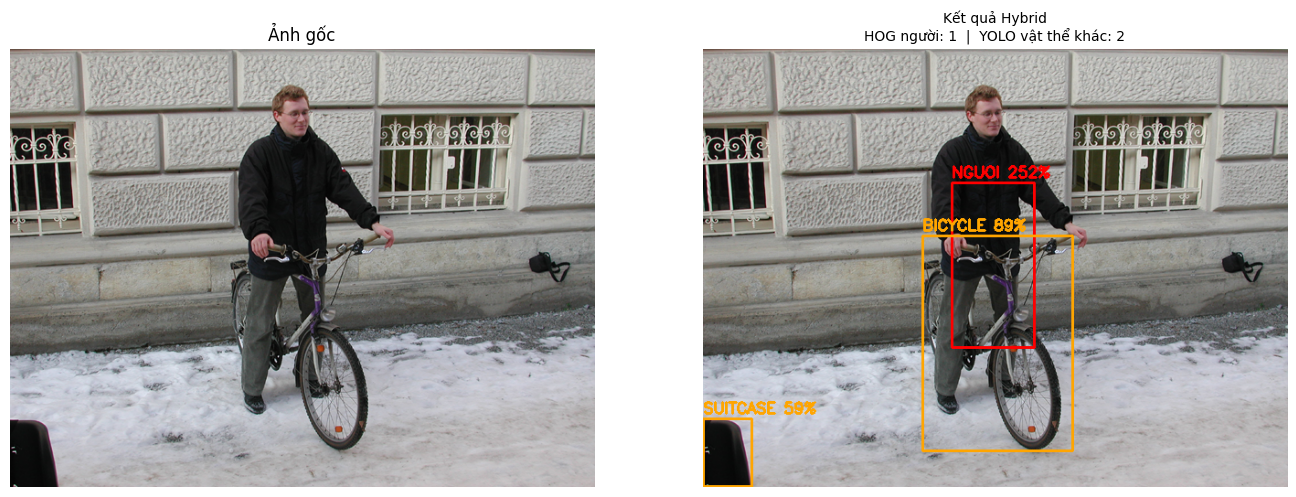


📊 Kết quả detect_hybrid:
   HOG+SVM  →  1 người
   YOLOv8   →  2 vật thể khác
              • bicycle (0.89)
              • suitcase (0.59)


In [21]:
# ===========================================================
# CELL 18 — DEMO HYBRID PIPELINE TRÊN ẢNH MẪU TRÊN ẢNH NGẪU NHIÊN
# ===========================================================
# Tạo frame giả lập để kiểm tra pipeline chạy không lỗi.
# Trong thực tế, thay `demo_frame` bằng frame từ webcam/video.

import urllib.request, io
from PIL import Image

# Tải ảnh mẫu từ INRIA test set (ảnh đầu tiên)
sample_paths = list(Path(DATASET_PATH).rglob('*.jpg'))[:1] + \
               list(Path(DATASET_PATH).rglob('*.png'))[:1]

if sample_paths:
    demo_frame = cv2.imread(str(sample_paths[0]))
    if demo_frame is None or demo_frame.size == 0:
        demo_frame = np.random.randint(60, 200, (480, 640, 3), dtype=np.uint8)
    print(f'📸 Dùng ảnh mẫu: {sample_paths[0].name}  {demo_frame.shape}')
else:
    demo_frame = np.random.randint(60, 200, (480, 640, 3), dtype=np.uint8)
    print('📸 Dùng frame ngẫu nhiên (không tìm thấy ảnh mẫu)')

# Chạy hybrid pipeline
vis_frame, results = detect_hybrid(
    demo_frame, hog_detector, yolo_model,
    yolo_conf=YOLO_CONF, yolo_iou=YOLO_IOU
)

# Hiển thị kết quả
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(demo_frame, cv2.COLOR_BGR2RGB))
axes[0].set_title('Ảnh gốc', fontsize=12)
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(vis_frame, cv2.COLOR_BGR2RGB))
axes[1].set_title(
    f'Kết quả Hybrid\n'
    f'HOG người: {len(results["persons_hog"])}  |  '
    f'YOLO vật thể khác: {len(results["objects_yolo"])}',
    fontsize=10
)
axes[1].axis('off')
plt.tight_layout()
plt.show()

print('\n📊 Kết quả detect_hybrid:')
print(f'   HOG+SVM  → {len(results["persons_hog"]):2d} người')
print(f'   YOLOv8   → {len(results["objects_yolo"]):2d} vật thể khác')
if results['objects_yolo']:
    for obj in results['objects_yolo']:
        print(f'              • {obj["label"]} ({obj["score"]:.2f})')


In [25]:
# ===========================================================
# CELL 19 — LƯU MODEL VỀ GOOGLE DRIVE VỀ GOOGLE DRIVE
# ===========================================================
# Format cv2.HOGDescriptor.setSVMDetector():
# w[-1] = -intercept   →   score = dot(w[:-1], x) - w[-1]  ≡  dot(coef, x) + intercept
if 'YOLO_BENCH_MS' not in dir():
    import time as _t
    _f = np.random.randint(50,200,(480,640,3),dtype=np.uint8)
    _t0 = _t.perf_counter()
    for _ in range(5): yolo_model(_f, conf=YOLO_CONF, iou=YOLO_IOU, verbose=False)
    YOLO_BENCH_MS = (_t.perf_counter()-_t0)*1000/5
    print(f'⚡ YOLO_BENCH_MS tự đo: {YOLO_BENCH_MS:.1f} ms')
svm_coef        = clf_final.coef_[0].astype(np.float64)
svm_intercept   = float(clf_final.intercept_[0])
svm_weights_cv2 = np.append(svm_coef, -svm_intercept).astype(np.float64)
assert len(svm_weights_cv2) == FEATURE_DIM + 1

model_bundle = {
    # ─ dùng trong app ─────────────────────────────────────
    'svm_weights'   : svm_weights_cv2,

    # ─ backup / debug ──────────────────────────────────────
    'svm_coef'      : svm_coef,
    'svm_intercept' : svm_intercept,

    # ─ HOG config (phải khớp với person_detector.py) ───────
    'hog_params': {
        'win_w'        : WIN_W,
        'win_h'        : WIN_H,
        'block_size'   : (BLOCK_W, BLOCK_H),
        'block_stride' : (BSTRIDE_W, BSTRIDE_H),
        'cell_size'    : (CELL_W, CELL_H),
        'n_bins'       : N_BINS,
        'feature_dim'  : FEATURE_DIM,
    },

    # ─ thông tin training (dùng cho báo cáo) ───────────────
    'training_info': {
        'dataset'           : 'INRIA Person Dataset (Kaggle: jcoral02/inriaperson)',
        'n_train_pos'       : len(X_pos_tr),
        'n_train_neg'       : len(X_neg_tr),
        'n_hard_neg'        : int(len(X_hard)),
        'total_train'       : len(X_tr2),
        'n_test_pos'        : len(X_pos_te),
        'n_test_neg'        : len(X_neg_te),
        'test_acc'          : round(float(acc), 4),
        'test_acc_pct'      : f"{acc:.2%}",
        'feature_dim'       : FEATURE_DIM,
        'fps_benchmark'     : round(float(fps), 1),
        'fps_hog_only'      : round(float(1000/hog_ms), 1),
        'flops_per_frame'   : int(total_flops),
        'flops_per_window'  : int(total_per_w),
        'windows_per_frame' : int(total_windows),
        'time_per_frame_ms' : round(float(tot_ms), 1),
        'svm_C'             : 0.01,
        'hard_neg_mining'   : True,
    },

    # ─ YOLOv8 config (dùng cho detect_hybrid) ──────────────────
    'yolo_config': {
        'weights'    : YOLO_WEIGHTS,
        'conf_thres' : YOLO_CONF,
        'iou_thres'  : YOLO_IOU,
        'n_classes'  : len(yolo_model.names),
        'fps_bench'  : round(float(1000/YOLO_BENCH_MS), 1),
        'role'       : 'Object detection (non-person classes)',
    },
}

save_path = f'{MODEL_SAVE_DIR}/hog_svm_model.pkl'
joblib.dump(model_bundle, save_path, compress=3)
size_kb = os.path.getsize(save_path) / 1024

print(f"✅ Model saved  →  {save_path}")
print(f"   File size    :  {size_kb:.0f} KB")
print(f"""
╔══════════════════════════════════════════════════════╗
║           📌 BƯỚC TIẾP THEO SAU KHI TRAIN           ║
╠══════════════════════════════════════════════════════╣
║  1. Vào Google Drive:                                ║
║     MyDrive → MotionGuardAI → models                 ║
║     Download file: hog_svm_model.pkl                 ║
║                                                      ║
║  2. Đặt vào project VS Code:                         ║
║     Proj_TNTT_Ver2/model/hog_svm_model.pkl           ║
║                                                      ║
║  3. Chạy app:                                        ║
║     pip install -r requirements.txt                  ║
║     python app.py                                    ║
║     → http://localhost:5000                          ║
╠══════════════════════════════════════════════════════╣
║  Test Accuracy  : {acc:.2%}                               ║
║  FPS (Colab)    : {fps:.1f} FPS                              ║
║  FLOPs/frame    : {total_flops/1e6:.0f} MFLOPs                       ║
╚══════════════════════════════════════════════════════╝
""")


⚡ YOLO_BENCH_MS tự đo: 199.1 ms
✅ Model saved  →  /content/drive/MyDrive/MotionGuardAI/models/hog_svm_model.pkl
   File size    :  30 KB

╔══════════════════════════════════════════════════════╗
║           📌 BƯỚC TIẾP THEO SAU KHI TRAIN           ║
╠══════════════════════════════════════════════════════╣
║  1. Vào Google Drive:                                ║
║     MyDrive → MotionGuardAI → models                 ║
║     Download file: hog_svm_model.pkl                 ║
║                                                      ║
║  2. Đặt vào project VS Code:                         ║
║     Proj_TNTT_Ver2/model/hog_svm_model.pkl           ║
║                                                      ║
║  3. Chạy app:                                        ║
║     pip install -r requirements.txt                  ║
║     python app.py                                    ║
║     → http://localhost:5000                          ║
╠══════════════════════════════════════════════════════╣
║  Test A